# Session 5
## Data Visualization
### Homework

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df_instacart = pd.read_csv('../data/processed/instacart.csv')


In [10]:
# Question 1: Which departments have products that are added to the cart earlier (higher priority)?
avg_add_to_cart_order_by_department = df_instacart.groupby("department")["add_to_cart_order"].mean().sort_values()
avg_add_to_cart_order_by_department.head()

department
alcohol       5.645127
beverages     7.136598
dairy eggs    7.877351
pets          7.939960
produce       8.431048
Name: add_to_cart_order, dtype: float64

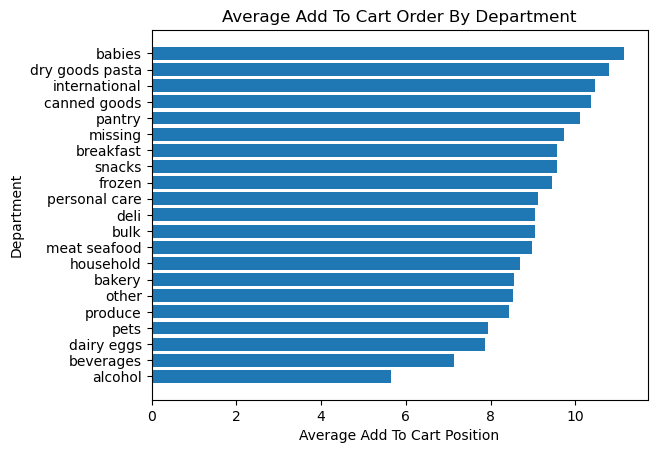

In [11]:
avg_add_to_cart_order_by_department = df_instacart.groupby("department")["add_to_cart_order"].mean().sort_values()

plt.figure()
plt.barh(avg_add_to_cart_order_by_department.index, avg_add_to_cart_order_by_department.values)
plt.title("Average Add To Cart Order By Department")
plt.xlabel("Average Add To Cart Position")
plt.ylabel("Department")
plt.show()


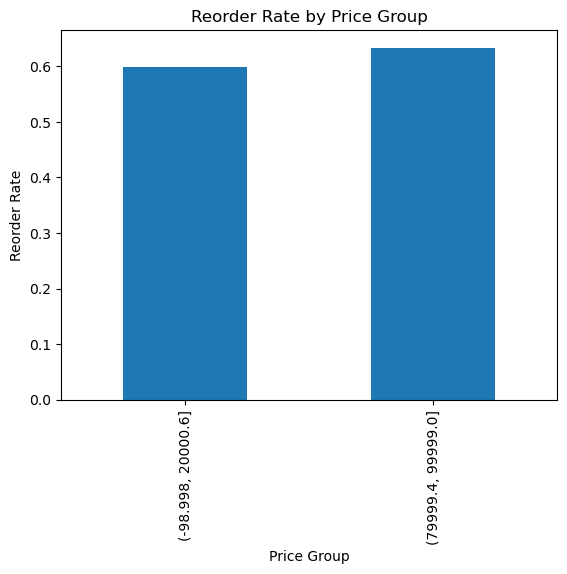

In [16]:
# Question 2:Is the reorder rate higher for cheaper products or more expensive ones?
df_instacart["price_group"] = pd.cut(df_instacart["prices"], bins=5)

reorder_by_price = df_instacart.groupby("price_group")["reordered"].mean()
plt.figure()
reorder_by_price.plot(kind="bar")
plt.title("Reorder Rate by Price Group")
plt.xlabel("Price Group")
plt.ylabel("Reorder Rate")
plt.show()

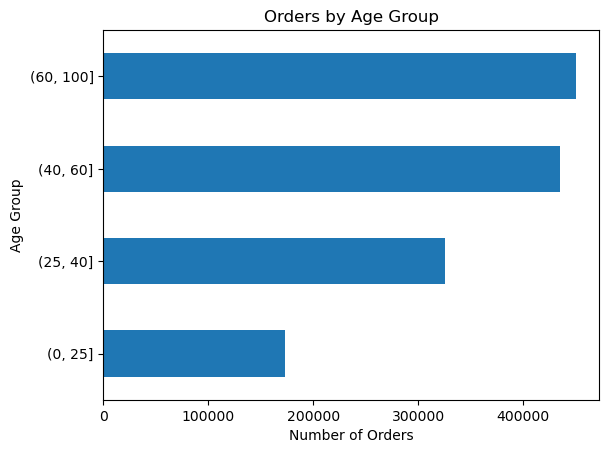

In [ ]:
# Question 3: Which age groups place the most orders?
df_instacart["age_group"] = pd.cut(df_instacart["Age"], bins=[0,25,40,60,100])
orders_by_age = df_instacart["age_group"].value_counts().sort_index()


plt.figure()
orders_by_age.plot(kind="barh")
plt.title("Orders by Age Group")
plt.xlabel("Number of Orders")
plt.ylabel("Age Group")
plt.show()

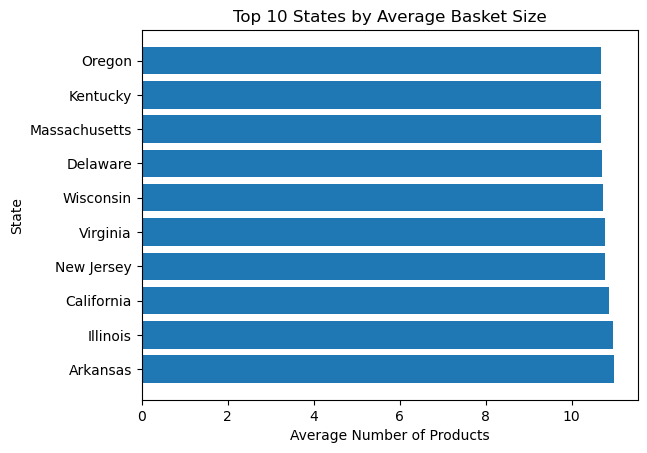

In [25]:
#Question 4: Which states have the highest average basket size (number of products per order)?
basket_size = df_instacart.groupby(["state","order_id"]).size().reset_index(name="basket_size")
avg_basket = basket_size.groupby("state")["basket_size"].mean()
top_10_states = avg_basket.sort_values(ascending = False).head(10)
plt.figure()
plt.barh(top_10_states.index, top_10_states.values)
plt.title("Top 10 States by Average Basket Size")
plt.xlabel("Average Number of Products")
plt.ylabel("State")

plt.show()

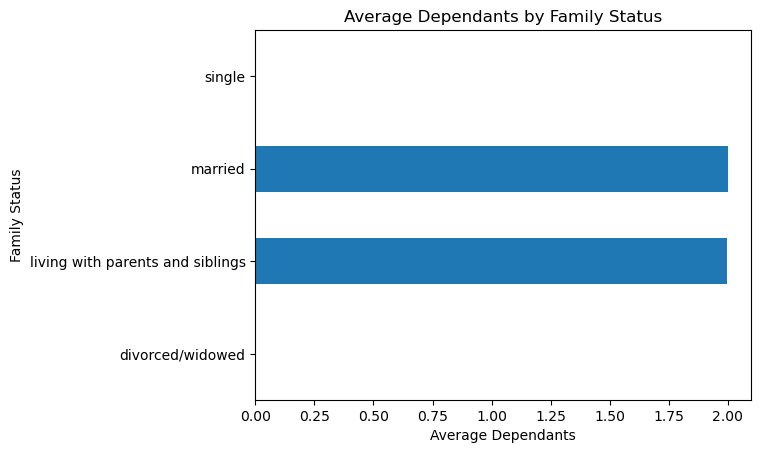

In [28]:
#Question 5: Is there a relationship between family status and the number of dependants?
dep_family = df_instacart.groupby("fam_status")["n_dependants"].mean()

plt.figure()
dep_family.plot(kind="barh")
plt.title("Average Dependants by Family Status")
plt.xlabel("Average Dependants")
plt.ylabel("Family Status")
plt.show()